# Tune $D_{sei}$ to get SEI quality for different formation protocols

2025/04/16

The plan:
1. Define an objective function as some combination of expansion error and voltage error
1. Sweep through different values of D_sei for VC only (just start with VC for now)
1. Plot D_sei vs error function for the three different formation protocols

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

from scipy.interpolate import interp1d

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils 
from src import simutils as simutils

%load_ext autoreload
%matplotlib widget

plotter.initialize(plt)

# Load the experimental data

In [2]:
from src import ioutils as ioutils

expt1, _ = ioutils.fetch_experimental_data(152064, 65)
# expt2 = fetch_experimental_data(152074)
expt3, _ = ioutils.fetch_experimental_data(152071, 16)
expt4, _ = ioutils.fetch_experimental_data(152098, 7)

In [3]:
dt_data_interp = 5.0

t_interp1, i_interp1 = simutils.interpolate_raw_data(expt1['arbin_time'], expt1['arbin_current'], dt_data_interp)
t_interp3, i_interp3 = simutils.interpolate_raw_data(expt3['arbin_time'], expt3['arbin_current'], dt_data_interp)
t_interp4, i_interp4 = simutils.interpolate_raw_data(expt4['arbin_time'], expt4['arbin_current'], dt_data_interp)


# Feed in experimental current to run a simulation

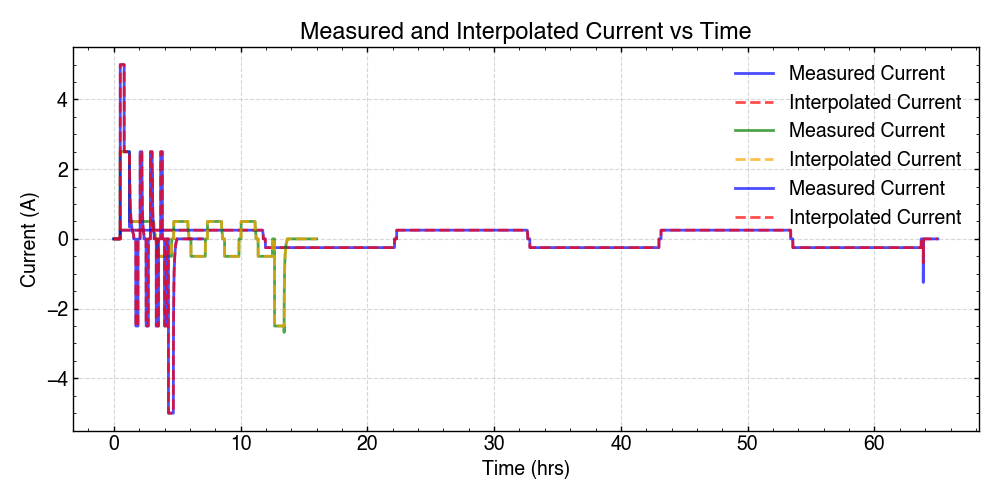

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(expt1['arbin_time'] / 3600, expt1['arbin_current'], label='Measured Current', color='blue', alpha=0.7)
plt.plot(t_interp1 / 3600, i_interp1, label='Interpolated Current', color='red', linestyle='--', alpha=0.7)
plt.plot(expt3['arbin_time'] / 3600, expt3['arbin_current'], label='Measured Current', color='green', alpha=0.7)
plt.plot(t_interp3 / 3600, i_interp3, label='Interpolated Current', color='orange', linestyle='--', alpha=0.7)
plt.plot(expt4['arbin_time'] / 3600, expt4['arbin_current'], label='Measured Current', color='blue', alpha=0.7)
plt.plot(t_interp4 / 3600, i_interp4, label='Interpolated Current', color='red', linestyle='--', alpha=0.7)
plt.xlabel('Time (hrs)')
plt.ylabel('Current (A)')
plt.title('Measured and Interpolated Current vs Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Simulate with measured current
Feed the experimental current vector into the simulation

In [ ]:
diff_ec = 4.2e-20
diff_vc = 6.6e-18 # For VC

# gamma_kappa = 4800
# gamma_kappa = 816
# gamma_kappa = 204
# gamma_kappa = 20000
gamma_kappa = 3367

df_sim1_timesync = simutils.run_sim('base', diff_ec, diff_vc, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp1)
df_sim2_timesync = simutils.run_sim('fast', diff_ec, diff_vc, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp3)
df_sim3_timesync = simutils.run_sim('fast+', diff_ec, diff_vc, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp4)

df_sim1 = simutils.run_sim('base', diff_ec, diff_vc, gamma_kappa)
df_sim2 = simutils.run_sim('fast', diff_ec, diff_vc, gamma_kappa)
df_sim3 = simutils.run_sim('fast+', diff_ec, diff_vc, gamma_kappa, dt=1)


In [ ]:
XLIM = (0, 30)
# Beware of experimental vs model data indexing!!
rmse1_v, tv1, sv1 = simutils.calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'], y_range=(3.0, 4.5))
rmse1t_v, tv1t, sv1t = simutils.calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1_timesync['t'], df_sim1_timesync['vt'], y_range=(3.0, 4.5))
rmse1_e, te1, se1 = simutils.calculate_rmse(expt1['daq_time'], expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
rmse1t_e, te1t, se1t = simutils.calculate_rmse(expt1['daq_time'], expt1['daq_strain'], df_sim1_timesync['t'], df_sim1_timesync['expansion']*1e6)

rmse2_v, tv2, sv2 = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'], y_range=(3.0, 4.5))
rmse2t_v, tv2t, sv2t = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2_timesync['t'], df_sim2_timesync['vt'], y_range=(3.0, 4.5))
rmse2_e, te2, se2 = simutils.calculate_rmse(expt3['daq_time'], expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
rmse2t_e, te2t, se2t = simutils.calculate_rmse(expt3['daq_time'], expt3['daq_strain'], df_sim2_timesync['t'], df_sim2_timesync['expansion']*1e6)

rmse3_v, tv3, sv3 = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'], y_range=(3.0, 4.5))
rmse3t_v, tv3t, sv3t = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3_timesync['t'], df_sim3_timesync['vt'], y_range=(3.0, 4.5))
rmse3_e, te3, se3 = simutils.calculate_rmse(expt4['daq_time'], expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)
rmse3t_e, te3t, se3t = simutils.calculate_rmse(expt4['daq_time'], expt4['daq_strain'], df_sim3_timesync['t'], df_sim3_timesync['expansion']*1e6)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Voltage plot
ax = axes[0, 0]
ax.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label=f'Base, RMSE = {rmse1_v:.2f} V')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label=f'Fast, RMSE = {rmse2_v:.2f} V')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label=f'Fast+, RMSE = {rmse3_v:.2f} V')
ax.plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['vt'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='')
ax.plot(df_sim1_timesync['t']/3600, df_sim1_timesync['vt'], color='k', ls=':', label='')
ax.plot(df_sim2_timesync['t']/3600, df_sim2_timesync['vt'], color='b', ls=':', label='')
ax.plot(df_sim3_timesync['t']/3600, df_sim3_timesync['vt'], color='r', ls=':', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Voltage (V)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend(fontsize=10)
ax.grid(False)

# Voltage error plot
ax = axes[0, 1]
ax.plot(tv1/3600, sv1, color='k', label=f'Base, RMSE1 = {rmse1_v:.2f} V')
ax.plot(tv1t/3600, sv1t, color='k', ls=':', label=f'Base, RMSE2 = {rmse1t_v:.2f} V')
ax.plot(tv2/3600, sv2, color='b', label=f'Fast, RMSE1 = {rmse2_v:.2f} V')
ax.plot(tv2t/3600, sv2t, color='b', ls=':', label=f'Fast, RMSE2 = {rmse2t_v:.2f} V')
ax.plot(tv3/3600, sv3, color='r', label=f'Fast+, RMSE1 = {rmse3_v:.2f} V')
ax.plot(tv3t/3600, sv3t, color='r', ls=':', label=f'Fast+, RMSE2 = {rmse3t_v:.2f} V')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Abs V Err (V)')
ax.set_xlim(XLIM)
ax.legend(fontsize=10)
ax.grid(False)

# Expansion plot
ax = axes[1, 0]
ax.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label=f'Base, RMSE = {rmse1_e:.2f} um')
ax.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um')
ax.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um')
ax.plot(df_sim1['t']/3600, (df_sim1['expansion'])*1e6, color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, (df_sim2['expansion'])*1e6, color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, (df_sim3['expansion'])*1e6, color='r', ls='--', label='')
ax.plot(df_sim1_timesync['t']/3600, (df_sim1_timesync['expansion'])*1e6, color='k', ls=':', label='')
ax.plot(df_sim2_timesync['t']/3600, (df_sim2_timesync['expansion'])*1e6, color='b', ls=':', label='')
ax.plot(df_sim3_timesync['t']/3600, (df_sim3_timesync['expansion'])*1e6, color='r', ls=':', label='')
ax.legend(fontsize=10)
ax.set_ylabel(r'Expansion ($\mu$m)')
ax.set_ylim(bottom=0, top=150)
ax.set_xlabel('Time (hrs)')
ax.set_xlim(XLIM)
ax.grid(False)

# Expansion error plot
ax = axes[1, 1]
ax.plot(te1/3600, se1, color='k', label=f'Base, RMSE = {rmse1_e:.2f} um')
ax.plot(te2/3600, se2, color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um')
ax.plot(te3/3600, se3, color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um')
ax.plot(te1t/3600, se1t, color='k', ls=':', label='')
ax.plot(te2t/3600, se2t, color='b', ls=':', label='')
ax.plot(te3t/3600, se3t, color='r', ls=':', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel(r'Abs Strain Err ($\mu$m)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend(fontsize=10)
ax.grid(False)

# Current plot
ax = axes[2, 0]
ax.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, df_sim1['i_app'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['i_app'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['i_app'], color='r', ls='--', label='')
ax.plot(df_sim1_timesync['t']/3600, df_sim1_timesync['i_app'], color='k', ls=':', label='')
ax.plot(df_sim2_timesync['t']/3600, df_sim2_timesync['i_app'], color='k', ls=':', label='')
ax.plot(df_sim3_timesync['t']/3600, df_sim3_timesync['i_app'], color='k', ls=':', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Current (A)')
ax.legend(fontsize=10)
ax.grid(False)
ax.set_xlim(XLIM)

# Empty plot for alignment
axes[2, 1].axis('off')

# Link all x-axes
for i in range(3):
    for j in range(2):
        if i > 0 or j > 0:
            axes[i, j].sharex(axes[0, 0])

plt.tight_layout()
plt.show()


# Search for the optimal SEI conductivity values to use

In [17]:

diff_ec = 3.162e-20  # Baseline d_ec from the latest study
diff_vc = 4.217e-16  # Baseline d_vc from the latest study

rs_meas1_base = 21.5e-3 
rs_meas1_fast = 17.7e-3
rs_meas1_fast_plus = 16.6e-3 

t_hppc1_base = 69.39*3600
t_hppc1_fast = 16.17*3600
t_hppc1_fast_plus = 7.465*3600
rs_meas1_time_base = t_hppc1_base + 54000
rs_meas1_time_fast = t_hppc1_fast + 54000
rs_meas1_time_fast_plus = t_hppc1_fast_plus + 54000
rs_meas2_time = 505.23 * 3600 + 5e4
rs_meas2_base = 0.0375
rs_meas2_fast = 0.0366
rs_meas2_fast_plus = 0.0366

nn = 60

kappa_ec_vec = np.linspace(5e-5, 5e-4, nn)
kappa_vc_vec = np.linspace(1e-5, 1e-4, nn+1)

err1_mat = np.zeros((len(kappa_ec_vec), len(kappa_vc_vec)))
err2_mat = np.zeros((len(kappa_ec_vec), len(kappa_vc_vec)))
err3_mat = np.zeros((len(kappa_ec_vec), len(kappa_vc_vec)))
count = 0

# With optimal d_ec and d_vc values
d_ec_opt1 = 3.2e-20  # Optimal d_ec for base
d_ec_opt2 = 3.2e-20  # Optimal d_ec for fast
d_ec_opt3 = 5.1e-20  # Optimal d_ec for fast+
d_vc_opt1 = 4.2e-16  # Optimal d_vc for base
d_vc_opt2 = 3.2e-17  # Optimal d_vc for fast
d_vc_opt3 = 3.2e-17  # Optimal d_vc for fast+

for i, kappa_ec in enumerate(kappa_ec_vec):
    for j, kappa_vc in enumerate(kappa_vc_vec):

        print(f'Running kappa_EC = {kappa_ec:.2e} m2/s and kappa_VC = {kappa_vc:.2e} ({count} of {nn*(nn+1)})')

        try:
            df_sim1 = simutils.run_sim('base', diff_ec=d_ec_opt1, diff_vc=d_vc_opt1, kappa_ec=kappa_ec, kappa_vc=kappa_vc, dt=5, include_flag=2)
            df_sim2 = simutils.run_sim('fast', diff_ec=d_ec_opt2, diff_vc=d_vc_opt2, kappa_ec=kappa_ec, kappa_vc=kappa_vc, dt=5, include_flag=2)
            df_sim3 = simutils.run_sim('fast+', diff_ec=d_ec_opt3, diff_vc=d_vc_opt3, kappa_ec=kappa_ec, kappa_vc=kappa_vc, dt=1, include_flag=2)
        except:
            print('ERROR')
            continue

        interp_rsei_base = interp1d(df_sim1['t'], df_sim1['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
        rs_modl1 = interp_rsei_base(rs_meas1_time_base)
        # rs_modl1n = interp_rsei_base(rs_meas2_time)
        # err1 = 0.5 * (np.abs(rs_modl1 - rs_meas1_base) + np.abs(rs_modl1n - rs_meas2_base))
        err1 = np.abs(rs_modl1 - rs_meas1_base)

        interp_rsei_fast = interp1d(df_sim2['t'], df_sim2['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
        rs_modl2 = interp_rsei_fast(rs_meas1_time_fast)
        # rs_modl2n = interp_rsei_fast(rs_meas2_time)
        # err2 = 0.5 * (np.abs(rs_modl2 - rs_meas1_fast) + np.abs(rs_modl2n - rs_meas2_fast))
        err2 = np.abs(rs_modl2 - rs_meas1_fast)

        interp_rsei_fast_plus = interp1d(df_sim3['t'], df_sim3['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
        rs_modl3 = interp_rsei_fast_plus(rs_meas1_time_fast_plus)
        # rs_modl3n = interp_rsei_fast_plus(rs_meas2_time)
        # err3 = 0.5 * (np.abs(rs_modl3 - rs_meas1_fast_plus) + np.abs(rs_modl3n - rs_meas2_fast_plus))
        err3 = np.abs(rs_modl3 - rs_meas1_fast_plus)

        err1_mat[i, j] = err1
        err2_mat[i, j] = err2
        err3_mat[i, j] = err3

        count += 1


# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(err1_mat == 0, np.nan, err1_mat)
rmse2_e_mat = np.where(err2_mat == 0, np.nan, err2_mat)
rmse3_e_mat = np.where(err3_mat == 0, np.nan, err3_mat)

Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.00e-05 (0 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.15e-05 (1 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.30e-05 (2 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.45e-05 (3 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.60e-05 (4 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.75e-05 (5 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.90e-05 (6 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.05e-05 (7 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.20e-05 (8 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.35e-05 (9 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.50e-05 (10 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.65e-05 (11 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.80e-05 (12 of 3660)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.95e-05 (13 of 3660)
Running kappa_EC = 5.00e-05 m2

In [18]:
# Pickle all variables to a file to save the simulation results
import pickle

variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse3_e_mat': rmse3_e_mat,
}

with open('outputs/resistance_optimization_results.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)

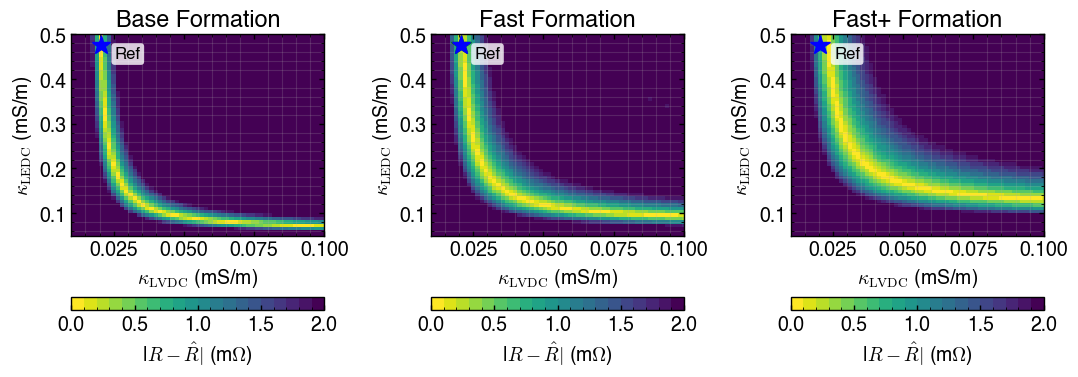

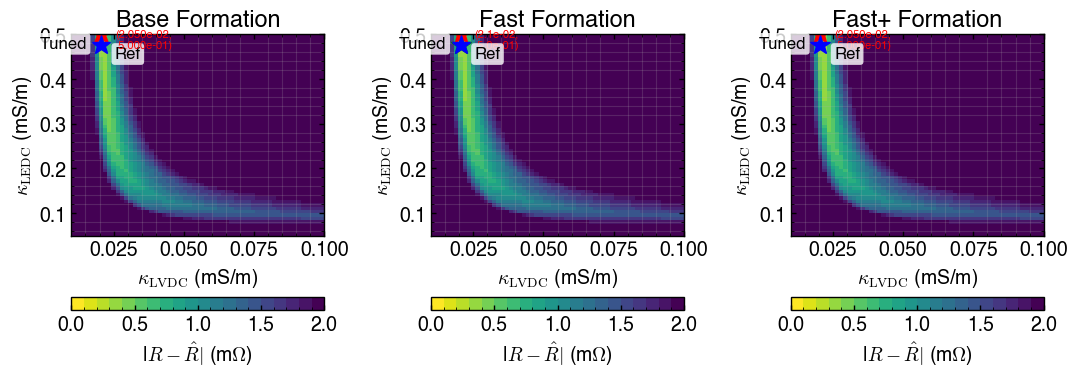

In [10]:
import pickle
%autoreload 2

%matplotlib inline
# Load the pickled simulation results
# with open('outputs/simulation_results.pkl', 'rb') as f:
with open('outputs/resistance_optimization_results.pkl', 'rb') as f:
    sim_results = pickle.load(f)

nn = 60
kappa_ec_vec = np.linspace(5e-5, 5e-4, nn)
kappa_vc_vec = np.linspace(1e-5, 1e-4, nn+1)

# Extract variables from the loaded results
rmse1_e_mat = sim_results['rmse1_e_mat']*1e3
rmse2_e_mat = sim_results['rmse2_e_mat']*1e3
rmse3_e_mat = sim_results['rmse3_e_mat']*1e3
rmse_avg = (rmse1_e_mat + rmse2_e_mat + rmse3_e_mat) / 3

simutils.plot_heatmaps(kappa_ec_vec*1e3, kappa_vc_vec*1e3, rmse1_e_mat, rmse2_e_mat, rmse3_e_mat, 
                                   r'|$R - \hat{R}|$ (m$\Omega$)', zmin=0.000, zmax=2, tosave=True,  
                                   savename='outputs/figures/heatmap_resistance_error.svg', to_annotate=False, to_show_tuned=False, is_kappa=True)

simutils.plot_heatmaps(kappa_ec_vec*1e3, kappa_vc_vec*1e3, rmse_avg, rmse_avg, rmse_avg,
                                   r'|$R - \hat{R}|$ (m$\Omega$)', zmin=0.000, zmax=2, tosave=True,  
                                   savename='outputs/figures/heatmap_resistance_error_avg.svg', to_annotate=True, is_kappa=True)

# Extract optimal values for kappa EC and kappa VC based on the map

In [30]:
idx_vc = np.where(kappa_vc_vec ==3.10e-05)[0][0]

idx_ec = np.argmin(rmse1_e_mat[idx_vc,:])
print(f'Base: Optimal (KEC|KVC): {kappa_ec_vec[idx_ec]:.3e} | {kappa_vc_vec[idx_vc]:.3e}')

idx_ec = np.argmin(rmse2_e_mat[idx_vc,:])
print(f'Fast: Optimal (KEC|KVC): {kappa_ec_vec[idx_ec]:.3e} | {kappa_vc_vec[idx_vc]:.3e}')

idx_ec = np.argmin(rmse3_e_mat[idx_vc,:])
print(f'Fast+: Optimal (KEC|KVC): {kappa_ec_vec[idx_ec]:.3e} | {kappa_vc_vec[idx_vc]:.3e}')

Base: Optimal (KEC|KVC): 1.492e-04 | 3.100e-05
Fast: Optimal (KEC|KVC): 1.797e-04 | 3.100e-05
Fast+: Optimal (KEC|KVC): 2.864e-04 | 3.100e-05


# Study some correlations

In [ ]:
# Create a table comparing SEI growth across different protocols
sim1_time1 = df_sim1['t'].iloc[-1]/3600
sim2_time1 = df_sim2['t'].iloc[-1]/3600
sim3_time1 = df_sim3['t'].iloc[-1]/3600

df_result = pd.DataFrame()

# Create column headers for different time points
time_points = ['2 hrs', 'After Formation Cycles']

protocols = []
total_sei = []
vc_pcts = []
D_sei1 = []
D_sei2 = []

 # Base formation (sim1)
for t in [2*3600, sim1_time1*3600]:
    q_sei = df_sim1[df_sim1['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim1[df_sim1['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Base')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim1[df_sim1['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim1[df_sim1['t'] <= t]['D_sei2'].iloc[-1])

# Fast formation (sim2)
for t in [2*3600, sim2_time1*3600]:
    q_sei = df_sim2[df_sim2['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim2[df_sim2['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim2[df_sim2['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim2[df_sim2['t'] <= t]['D_sei2'].iloc[-1])

# Fast+ formation (sim3)
for t in [2*3600, sim3_time1*3600]:
    q_sei = df_sim3[df_sim3['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim3[df_sim3['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast+')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim3[df_sim3['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim3[df_sim3['t'] <= t]['D_sei2'].iloc[-1])


df_result = pd.DataFrame({
    'Protocol': protocols,
    'Time Point': time_points * 3,
    'Total SEI (Ah)': total_sei,
    'VC SEI %': vc_pcts,
    'D_sei1': D_sei1,
    'D_sei2': D_sei2
})


print(df_result.to_string(index=False))

# Study sensitivity of model error to choice of {DSEI1, DSEI2}

## Simulate protocols

In [4]:
# Extend the dataset to include in the study
expt1, df1 = ioutils.fetch_experimental_data(152064, 400)
# expt2 = fetch_experimental_data(152074, 400)
expt3, df3 = ioutils.fetch_experimental_data(152071, 400)
expt4, df4 = ioutils.fetch_experimental_data(152098, 400)


dt_data_interp = 5.0
t_interp1, i_interp1 = simutils.interpolate_raw_data(expt1['arbin_time'], expt1['arbin_current'], dt_data_interp)
t_interp3, i_interp3 = simutils.interpolate_raw_data(expt3['arbin_time'], expt3['arbin_current'], dt_data_interp)
t_interp4, i_interp4 = simutils.interpolate_raw_data(expt4['arbin_time'], expt4['arbin_current'], dt_data_interp)


In [5]:
nn = 40

diff_ec_vec = np.logspace(-22, -17, nn)
diff_vc_vec = np.logspace(-21, -12, nn+1)

rmse1_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse1_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

expan1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

resistance1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
resistance2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))   
resistance3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

count = 1

for i, diff_ec in enumerate(diff_ec_vec):
    for j, diff_vc in enumerate(diff_vc_vec):

        print(f'Running D_EC = {diff_ec:.2e} m2/s and D_VC = {diff_vc:.2e} m2/s ({count} of {nn*(nn+1)})')
        count += 1

        try:
            df_sim1 = simutils.run_sim('base', diff_ec, diff_vc, dt=5, include_flag=3)
            df_sim2 = simutils.run_sim('fast', diff_ec, diff_vc, dt=5, include_flag=3)
            df_sim3 = simutils.run_sim('fast+', diff_ec, diff_vc, dt=1, include_flag=3)
        except:
            print('ERROR')
            continue

        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!!
        rmse1_v, _, _ = simutils.calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
        rmse1_e, _, _ = simutils.calculate_rmse(expt1['daq_time'],   expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
        rmse2_v, _, _ = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
        rmse2_e, _, _ = simutils.calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
        rmse3_v, _, _ = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
        rmse3_e, _, _ = simutils.calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

expan1_mat = np.where(expan1_mat == 0, np.nan, expan1_mat)
expan2_mat = np.where(expan2_mat == 0, np.nan, expan2_mat)
expan3_mat = np.where(expan3_mat == 0, np.nan, expan3_mat)

resistance1_mat = np.where(resistance1_mat == 0, np.nan, resistance1_mat)
resistance2_mat = np.where(resistance2_mat == 0, np.nan, resistance2_mat)
resistance3_mat = np.where(resistance3_mat == 0, np.nan, resistance3_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

Running D_EC = 1.00e-22 m2/s and D_VC = 1.00e-21 m2/s (1 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.68e-21 m2/s (2 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 2.82e-21 m2/s (3 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 4.73e-21 m2/s (4 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 7.94e-21 m2/s (5 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.33e-20 m2/s (6 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 2.24e-20 m2/s (7 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 3.76e-20 m2/s (8 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 6.31e-20 m2/s (9 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.06e-19 m2/s (10 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.78e-19 m2/s (11 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 2.99e-19 m2/s (12 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 5.01e-19 m2/s (13 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 8.41e-19 m2/s (14 of 1640)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.41e-18 m2/s (15 of 1640)
Runn

/Users/ampere/code/formation-modeling/src/cellsim.py:290: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:291: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])


Running D_EC = 7.02e-19 m2/s and D_VC = 1.00e-21 m2/s (1231 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 1.68e-21 m2/s (1232 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 2.82e-21 m2/s (1233 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 4.73e-21 m2/s (1234 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 7.94e-21 m2/s (1235 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 1.33e-20 m2/s (1236 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 2.24e-20 m2/s (1237 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 3.76e-20 m2/s (1238 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 6.31e-20 m2/s (1239 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 1.06e-19 m2/s (1240 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 1.78e-19 m2/s (1241 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 2.99e-19 m2/s (1242 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 5.01e-19 m2/s (1243 of 1640)
Running D_EC = 7.02e-19 m2/s and D_VC = 8.41e-19 m2/s (1244 of 1640)
Running D_EC = 7.02e-19 m2/s and D

/Users/ampere/code/formation-modeling/src/cellsim.py:290: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:291: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:290: RuntimeWarning: overflow encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:291: RuntimeWarning: overflow encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])


Running D_EC = 7.02e-19 m2/s and D_VC = 5.96e-13 m2/s (1270 of 1640)
ERROR
Running D_EC = 7.02e-19 m2/s and D_VC = 1.00e-12 m2/s (1271 of 1640)
ERROR
Running D_EC = 9.43e-19 m2/s and D_VC = 1.00e-21 m2/s (1272 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 1.68e-21 m2/s (1273 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 2.82e-21 m2/s (1274 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 4.73e-21 m2/s (1275 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 7.94e-21 m2/s (1276 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 1.33e-20 m2/s (1277 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 2.24e-20 m2/s (1278 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 3.76e-20 m2/s (1279 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 6.31e-20 m2/s (1280 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 1.06e-19 m2/s (1281 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 1.78e-19 m2/s (1282 of 1640)
Running D_EC = 9.43e-19 m2/s and D_VC = 2.99e-19 m2/s (1283 of 1640)
Running D_EC = 9.43e-1

...

ERROR
Running D_EC = 1.00e-17 m2/s and D_VC = 7.50e-14 m2/s (1635 of 1640)


/Users/ampere/code/formation-modeling/src/cellsim.py:333: RuntimeWarning: overflow encountered in scalar divide
  self.D_sei1[k+1] = 1 / (mu1/p.D_SEI11 + mu2/p.D_SEI12)
/Users/ampere/code/formation-modeling/src/cellsim.py:334: RuntimeWarning: overflow encountered in scalar divide
  self.D_sei2[k+1] = 1 / (mu1/p.D_SEI21 + mu2/p.D_SEI22)


Running D_EC = 1.00e-17 m2/s and D_VC = 1.26e-13 m2/s (1636 of 1640)
ERROR
Running D_EC = 1.00e-17 m2/s and D_VC = 2.11e-13 m2/s (1637 of 1640)


/Users/ampere/code/formation-modeling/src/cellsim.py:290: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:291: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:271: RuntimeWarning: overflow encountered in exp
  * np.exp( -p.alpha_SEI * p.n_SEI1 * \
/Users/ampere/code/formation-modeling/src/cellsim.py:281: RuntimeWarning: overflow encountered in exp
  * np.exp( -p.alpha_SEI * p.n_SEI2 * \


ERROR
Running D_EC = 1.00e-17 m2/s and D_VC = 3.55e-13 m2/s (1638 of 1640)
ERROR
Running D_EC = 1.00e-17 m2/s and D_VC = 5.96e-13 m2/s (1639 of 1640)
ERROR
Running D_EC = 1.00e-17 m2/s and D_VC = 1.00e-12 m2/s (1640 of 1640)
ERROR


# Create a scatterplot of expansion, capacity, and resistance, for all simulated combinations of {DSEI1, DSEI2}

In [ ]:
qsei1_flat = qsei1_mat.flatten()
qsei2_flat = qsei2_mat.flatten()
qsei3_flat = qsei3_mat.flatten()

expan1_flat = expan1_mat.flatten()
expan2_flat = expan2_mat.flatten()
expan3_flat = expan3_mat.flatten()

resistance1_flat = resistance1_mat.flatten()
resistance2_flat = resistance2_mat.flatten()
resistance3_flat = resistance3_mat.flatten()

plt.figure(figsize=(8, 6))
plt.scatter(qsei1_flat, expan1_flat*1e6, alpha=0.7, edgecolors='k', label='Base')
plt.scatter(qsei2_flat, expan2_flat*1e6, alpha=0.7, edgecolors='k', label='Fast')
plt.scatter(qsei3_flat, expan3_flat*1e6, alpha=0.7, edgecolors='k', label='Fast+')
plt.xlabel('Q_SEI (Ah)')
plt.ylabel('Expansion (um)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(qsei1_flat, resistance1_flat, alpha=0.7, edgecolors='k', label='Base')
plt.scatter(qsei2_flat, resistance2_flat, alpha=0.7, edgecolors='k', label='Fast')
plt.scatter(qsei3_flat, resistance3_flat, alpha=0.7, edgecolors='k', label='Fast+')
plt.xlabel('Q_SEI (Ah)')
plt.ylabel('Resistance (Ohms)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.ylim((0, 0.2))
plt.show()

# Prepare data for plotting {DSEI, DSEI2} heatmaps

### Cache simulation outputs to disk

In [7]:
# Pickle all variables to a file to save the simulation results
import pickle

variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse1_v_mat': rmse1_v_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse2_v_mat': rmse2_v_mat,
    'rmse3_e_mat': rmse3_e_mat,
    'rmse3_v_mat': rmse3_v_mat,
    'qsei1_mat': qsei1_mat,
    'qsei2_mat': qsei2_mat,
    'qsei3_mat': qsei3_mat,
    'qsei1_vc_mat': qsei1_vc_mat,
    'qsei2_vc_mat': qsei2_vc_mat,
    'qsei3_vc_mat': qsei3_vc_mat,
    'expan1_mat': expan1_mat,
    'expan2_mat': expan2_mat,
    'expan3_mat': expan3_mat,
    'resistance1_mat': resistance1_mat,
    'resistance2_mat': resistance2_mat,
    'resistance3_mat': resistance3_mat,
    'combined_rmse1': combined_rmse1,
    'combined_rmse2': combined_rmse2,
    'combined_rmse3': combined_rmse3,
    'eq1_mat': eq1_mat,
    'eq2_mat': eq2_mat,
    'eq3_mat': eq3_mat,
    'er1_mat': er1_mat,
    'er2_mat': er2_mat,
    'er3_mat': er3_mat,
    'ec1_mat': ec1_mat,
    'ec2_mat': ec2_mat,
    'ec3_mat': ec3_mat,
}

with open('outputs/simulation_results_20250817.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)

# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

expan1_mat = np.where(expan1_mat == 0, np.nan, expan1_mat)
expan2_mat = np.where(expan2_mat == 0, np.nan, expan2_mat)
expan3_mat = np.where(expan3_mat == 0, np.nan, expan3_mat)

resistance1_mat = np.where(resistance1_mat == 0, np.nan, resistance1_mat)
resistance2_mat = np.where(resistance2_mat == 0, np.nan, resistance2_mat)
resistance3_mat = np.where(resistance3_mat == 0, np.nan, resistance3_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

### Read simulation outputs from disk

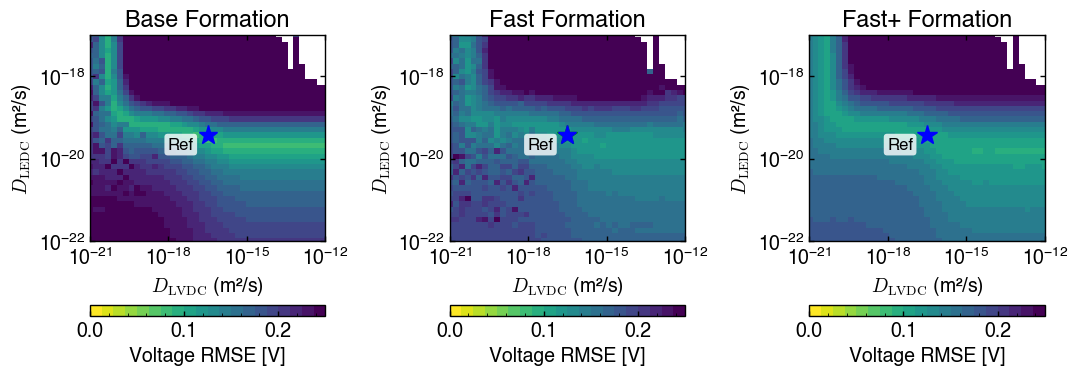

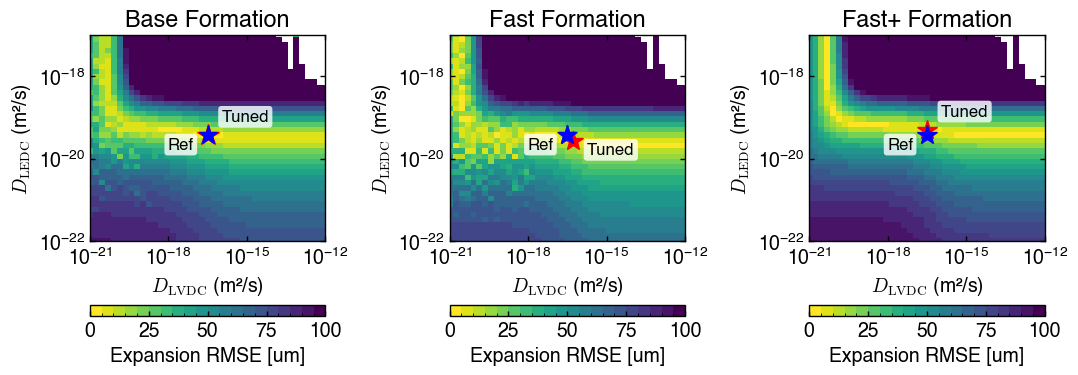

In [15]:
import pickle
%autoreload 2

%matplotlib inline
# Load the pickled simulation results
# with open('outputs/simulation_results_20240627.pkl', 'rb') as f:
with open('outputs/simulation_results_20250817.pkl', 'rb') as f:
    sim_results = pickle.load(f)
diff_ec_vec = np.logspace(-22, -17, 40)
diff_vc_vec = np.logspace(-21, -12, 41)

# with open('outputs/simulation_results.pkl', 'rb') as f:
    # sim_results = pickle.load(f)
# diff_ec_vec = np.logspace(-22, -17, 25)
# diff_vc_vec = np.logspace(-21, -12, 25)


# Extract variables from the loaded results
rmse1_e_mat = sim_results['rmse1_e_mat']
rmse1_v_mat = sim_results['rmse1_v_mat']
rmse2_e_mat = sim_results['rmse2_e_mat'] 
rmse2_v_mat = sim_results['rmse2_v_mat']
rmse3_e_mat = sim_results['rmse3_e_mat']
rmse3_v_mat = sim_results['rmse3_v_mat']
qsei1_mat = sim_results['qsei1_mat']
qsei2_mat = sim_results['qsei2_mat']
qsei3_mat = sim_results['qsei3_mat']
qsei1_vc_mat = sim_results['qsei1_vc_mat']
qsei2_vc_mat = sim_results['qsei2_vc_mat']
qsei3_vc_mat = sim_results['qsei3_vc_mat']
expan1_mat = sim_results['expan1_mat']
expan2_mat = sim_results['expan2_mat']
expan3_mat = sim_results['expan3_mat']
resistance1_mat = sim_results['resistance1_mat']
resistance2_mat = sim_results['resistance2_mat']
resistance3_mat = sim_results['resistance3_mat']
combined_rmse1 = sim_results['combined_rmse1']
combined_rmse2 = sim_results['combined_rmse2']
combined_rmse3 = sim_results['combined_rmse3']
eq1_mat = sim_results['eq1_mat']
eq2_mat = sim_results['eq2_mat']
eq3_mat = sim_results['eq3_mat']
er1_mat = sim_results['er1_mat'] 
er2_mat = sim_results['er2_mat']
er3_mat = sim_results['er3_mat']
ec1_mat = sim_results['ec1_mat']
ec2_mat = sim_results['ec2_mat']
ec3_mat = sim_results['ec3_mat']



simutils.plot_heatmaps(diff_ec_vec, diff_vc_vec, rmse1_v_mat, rmse2_v_mat, rmse3_v_mat, 'Voltage RMSE [V]', 
                                   zmin=0, zmax=0.250, tosave=True, savename='outputs/figures/heatmap_rmse_v.svg', 
                                   to_annotate=False, to_show_tuned=False)
simutils.plot_heatmaps(diff_ec_vec, diff_vc_vec, rmse1_e_mat, rmse2_e_mat, rmse3_e_mat, 'Expansion RMSE [um]', 
                                   zmin=0, zmax=100, tosave=True, savename='outputs/figures/heatmap_rmse_e.svg', 
                                   to_annotate=False, to_show_tuned=True)

# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, eq1_mat, eq2_mat, eq3_mat, '$E_Q = (Q-\hat{Q})^2$', zmin=0, zmax=0.2, tosave=True, savename='heatmap_eq.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, er1_mat, er2_mat, er3_mat, '$E_R = (R-\hat{R})^2$', zmin=0, zmax=0.01, tosave=True, savename='heatmap_er.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, ec1_mat, ec2_mat, ec3_mat, '$E_Q + E_R$', zmin=0.0, zmax=0.05, tosave=True, savename='heatmap_ec.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, combined_rmse1, combined_rmse2, combined_rmse3, '$RMSE_V + RMSE_{\epsilon}$', zmin=0.00, zmax=0.5, tosave=True, savename='heatmap_combined_rmse.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, qsei1_vc_mat, qsei2_vc_mat, qsei3_vc_mat, '$Q_{VC}$', is_error_plot=False, tosave=True, savename='heatmap_qsei_vc.svg')